Predicting how node will act in the next round 

# Imports

In [29]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import pandas as pd
import networkx as nx
from matplotlib import pyplot as plt
import numpy as np
from torch_geometric.data import Data
from torch_geometric.data import InMemoryDataset
import torch.nn as nn
from torch_geometric.data import InMemoryDataset, Data

# Data Prep

In [30]:
def build_graph_data(df, round_num):
    round_t = df[df['round'] == round_num]
    round_t_plus_1 = df[df['round'] == round_num + 1]

    if round_t_plus_1.empty:  # No labels for last round
        return None
    G = nx.watts_strogatz_graph(n=round_t['node'].nunique(), k=4, p=0.3)  
    feats = round_t[['degree', 'payoff', 'prev_payoff', 'coop_neighbors', 'defector_neighbors']].values
    strategies = round_t['strategy_type'].values

    labels = round_t_plus_1['current_action'].values # current_action of next round (thats what we're trying to predict)
    return G, feats, labels, strategies


In [31]:
df = pd.read_csv('../data/agent_simulation200.csv')
graphs, features, labels, strategies = [], [], [], []
for r in range(df['round'].max()):
    result = build_graph_data(df, r)
    if result:
        G, feats, lbls, strategy = result
        graphs.append(G)
        features.append(feats)
        labels.append(lbls)
        strategies.append(strategy)

In [33]:
def nx_to_pyg_data(G, node_features, labels):
    edge_index = torch.tensor(list(G.edges)).t().contiguous()
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)  
    x = torch.tensor(node_features, dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

class PDGraphDataset(InMemoryDataset):
    def __init__(self, graphs, features, labels, transform=None):
        super(PDGraphDataset, self).__init__('.', transform)
        data_list = []
        for G, feats, lbls in zip(graphs, features, labels):
            data = nx_to_pyg_data(G, feats, lbls)
            data_list.append(data)
        self.data, self.slices = self.collate(data_list)


# Define model

In [34]:
class PDGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(PDGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, 1)  # Binary classification

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.classifier(x)
        return torch.sigmoid(x).squeeze()  # Output shape: (num_nodes,)


## Train model

In [35]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out, data.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index)
            pred = (out > 0.5).long()
            correct += (pred == data.y).sum().item()
            total += data.y.size(0)
    return correct / total


In [ ]:
from torch_geometric.loader import DataLoader

# Assuming you have your graphs, features, labels from your simulation
dataset = PDGraphDataset(graphs, features, labels)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

model = PDGCN(in_channels=features[0].shape[1], hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCELoss()

for epoch in range(20):
    loss = train(model, loader, optimizer, criterion)
    acc = evaluate(model, loader)
    print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")
 

Epoch 0, Loss: 0.5907, Accuracy: 0.7113
Epoch 1, Loss: 0.5757, Accuracy: 0.7092
Epoch 2, Loss: 0.5723, Accuracy: 0.7206
Epoch 3, Loss: 0.5670, Accuracy: 0.6998
Epoch 4, Loss: 0.5658, Accuracy: 0.7240
Epoch 5, Loss: 0.5647, Accuracy: 0.7273
Epoch 6, Loss: 0.5590, Accuracy: 0.7304
Epoch 7, Loss: 0.5569, Accuracy: 0.7340
Epoch 8, Loss: 0.5531, Accuracy: 0.7328
Epoch 9, Loss: 0.5508, Accuracy: 0.7339
Epoch 10, Loss: 0.5554, Accuracy: 0.7276
Epoch 11, Loss: 0.5447, Accuracy: 0.7370
Epoch 12, Loss: 0.5512, Accuracy: 0.7360
Epoch 13, Loss: 0.5493, Accuracy: 0.7268
Epoch 14, Loss: 0.5509, Accuracy: 0.7383
Epoch 15, Loss: 0.5478, Accuracy: 0.6946
Epoch 16, Loss: 0.5450, Accuracy: 0.7368
Epoch 17, Loss: 0.5460, Accuracy: 0.7317
Epoch 18, Loss: 0.5466, Accuracy: 0.7371
Epoch 19, Loss: 0.5481, Accuracy: 0.7048


In [37]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_with_metrics(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index)
            preds = (out > 0.5).long()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)


              precision    recall  f1-score   support

      Defect       0.63      0.89      0.74      4608
   Cooperate       0.85      0.55      0.66      5342

    accuracy                           0.70      9950
   macro avg       0.74      0.72      0.70      9950
weighted avg       0.75      0.70      0.70      9950



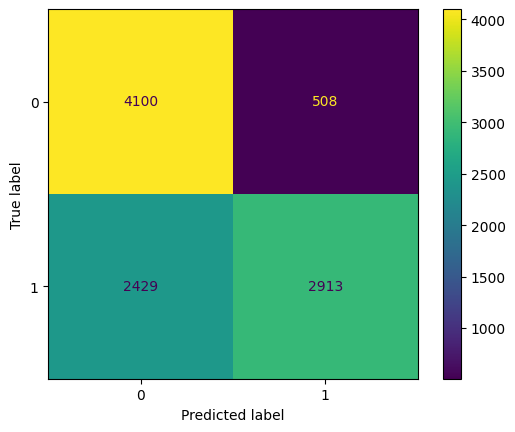

In [38]:
preds, labels = evaluate_with_metrics(model, loader)

cm = confusion_matrix(labels, preds)
ConfusionMatrixDisplay(cm).plot()

print(classification_report(labels, preds, target_names=["Defect", "Cooperate"]))


In [39]:
def evaluate_by_strategy(model, loader):
    model.eval()
    strategy_preds = {}
    strategy_labels = {}
    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index)
            preds = (out > 0.5).long().cpu().numpy()
            labels = data.y.cpu().numpy()
            strategy_col = data.x[:, -1].cpu().numpy().astype(int)
            for s in np.unique(strategy_col):
                mask = strategy_col == s
                strategy_preds.setdefault(s, []).extend(preds[mask])
                strategy_labels.setdefault(s, []).extend(labels[mask])
    
    for strategy, preds in strategy_preds.items():
        labels = strategy_labels[strategy]
        print(f"\nStrategy {strategy}:")
        print(classification_report(labels, preds, target_names=["Defect", "Cooperate"]))
    return strategy_preds, strategy_labels



Strategy 0:
              precision    recall  f1-score   support

      Defect       0.23      0.17      0.19        83
   Cooperate       0.85      0.89      0.87       441

    accuracy                           0.78       524
   macro avg       0.54      0.53      0.53       524
weighted avg       0.75      0.78      0.76       524


Strategy 1:
              precision    recall  f1-score   support

      Defect       0.37      0.47      0.42       353
   Cooperate       0.87      0.81      0.84      1521

    accuracy                           0.75      1874
   macro avg       0.62      0.64      0.63      1874
weighted avg       0.78      0.75      0.76      1874


Strategy 2:
              precision    recall  f1-score   support

      Defect       0.64      0.86      0.73       885
   Cooperate       0.85      0.63      0.72      1132

    accuracy                           0.73      2017
   macro avg       0.75      0.74      0.73      2017
weighted avg       0.76      0.73  

c:\Users\aquaf\anaconda3\envs\gnn_prisoner\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\aquaf\anaconda3\envs\gnn_prisoner\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\aquaf\anaconda3\envs\gnn_prisoner\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

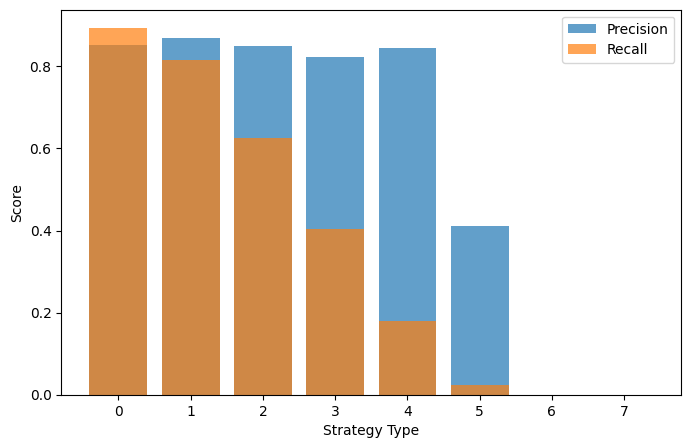

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

strategies = []
precisions = []
recalls = []

strategy_preds, strategy_labels = evaluate_by_strategy(model, loader)
for strategy, preds in strategy_preds.items():
    labels = strategy_labels[strategy]
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    strategies.append(strategy)
    precisions.append(precision)
    recalls.append(recall)

plt.figure(figsize=(8,5))
plt.bar(strategies, precisions, label='Precision', alpha=0.7)
plt.bar(strategies, recalls, label='Recall', alpha=0.7)
plt.xlabel('Strategy Type')
plt.ylabel('Score')
plt.legend()
plt.show()
